In [25]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from pca_utils import plot_widget
from bokeh.io import show, output_notebook
from bokeh.plotting import figure
import matplotlib.pyplot as plt
import plotly.offline as py

In [26]:
py.init_notebook_mode()

In [27]:
output_notebook()

Loading BokehJS ...

In [28]:
#Example
X = np.array([[99, -1],
[98, -1],
[97, -2],
[101, 1],
[102, 1],
[103, 2]])


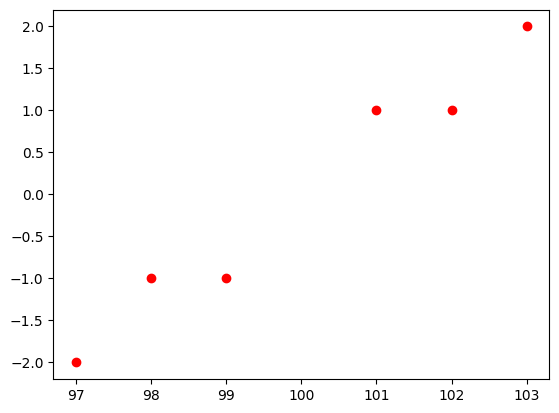

In [29]:
plt.plot(X[:,0], X[:,1], 'ro')

In [30]:
#load the PCA algorithm
pca_2 = PCA(n_components=2)  #2D
pca_2

PCA(n_components=2)

In [31]:
#fit the data. We do not need to scale is(sklearn's implementation already handles that)
pca_2.fit(X)

PCA(n_components=2)

In [32]:
pca_2.explained_variance_ratio_

array([0.99244289, 0.00755711])

In [ ]:
#observation
# The first principal component(first axis) ratins 99.24% of the information(eplained variance)
# The 2nd principal component adds 0.76% of info(explained variance) 

In [33]:
X_trans_2 = pca_2.transform(X)
X_trans_2

array([[-1.38340578, -0.2935787 ],
       [-2.22189802,  0.25133484],
       [-3.6053038 , -0.04224385],
       [ 1.38340578,  0.2935787 ],
       [ 2.22189802, -0.25133484],
       [ 3.6053038 ,  0.04224385]])

In [34]:
#choose the 1st pricnipal component since it retains 99% of the information(explined variance)
pca_1 = PCA(n_components=1)
pca_1

PCA(n_components=1)

In [35]:
pca_1.fit(X)
pca_1.explained_variance_ratio_

array([0.99244289])

In [36]:
X_trans_1 = pca_1.transform(X)
X_trans_1

array([[-1.38340578],
       [-2.22189802],
       [-3.6053038 ],
       [ 1.38340578],
       [ 2.22189802],
       [ 3.6053038 ]])

In [ ]:
#observation
# X_trans_1 is a replica of X_trans_2

In [38]:
X_reduced_2 = pca_2.inverse_transform(X_trans_2)
X_reduced_2

array([[ 99.,  -1.],
       [ 98.,  -1.],
       [ 97.,  -2.],
       [101.,   1.],
       [102.,   1.],
       [103.,   2.]])

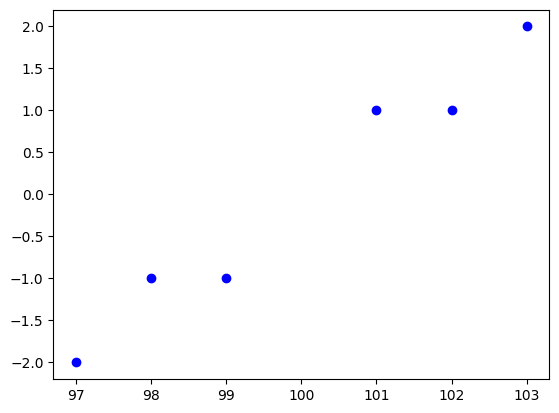

In [39]:
plt.plot(X_reduced_2[:,0], X_reduced_2[:,1], 'bo')

In [40]:
#reduce 1D instead of 2D
X_reduced_1 = pca_1.inverse_transform(X_trans_1)
X_reduced_1

array([[ 98.84002499,  -0.75383654],
       [ 98.13695576,  -1.21074232],
       [ 96.97698075,  -1.96457886],
       [101.15997501,   0.75383654],
       [101.86304424,   1.21074232],
       [103.02301925,   1.96457886]])

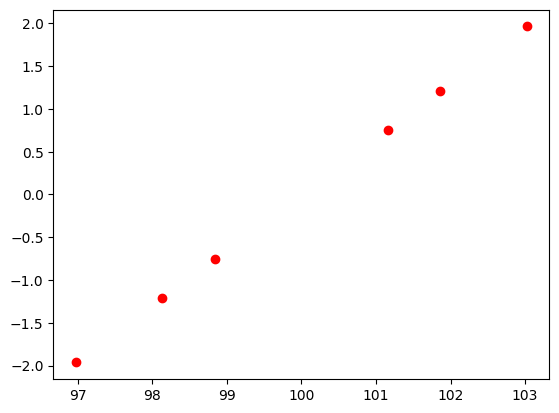

In [41]:
plt.plot(X_reduced_1[:,0], X_reduced_1[:,1], 'ro')

In [ ]:
#The data is now a single line(single principal component), with
# a single coordinate along the axis to describe its location

In [42]:
#VISUALIZING THE PCA COMPONENT
X = np.array([[-0.83934975, -0.21160323],
       [ 0.67508491,  0.25113527],
       [-0.05495253,  0.36339613],
       [-0.57524042,  0.24450324],
       [ 0.58468572,  0.95337657],
       [ 0.5663363 ,  0.07555096],
       [-0.50228538, -0.65749982],
       [-0.14075593,  0.02713815],
       [ 0.2587186 , -0.26890678],
       [ 0.02775847, -0.77709049]])

In [43]:
#create the figure object
p = figure(title = '10-point scatterplot', x_axis_label = 'x-axis', y_axis_label = 'y_axis')
p.scatter(X[:, 0], X[:, 1], marker='o', color='#C00000', size=5)  #add the scatter plot

#Some visual adjustments
p.grid.visible = False
p.grid.visible = False
p.outline_line_color = None
p.toolbar.logo = None
p.toolbar_location = None
p.xaxis.axis_line_color = '#f0f0f0'
p.xaxis.axis_line_width = 5
p.yaxis.axis_line_color = '#f0f0f0'
p.yaxis.axis_line_width = 5

#show the figure
show(p)

In [ ]:
#widget to show different ways of compressing this data into 1D datapoints
plot_widget()

In [45]:
#VISUALIZING A 3D DATASET
from pca_utils import random_point_circle, plot_3d_2d_graphs

In [46]:
X = random_point_circle(n = 150)

In [47]:
deb = plot_3d_2d_graphs(X)

In [48]:
deb.update_layout(yaxis2 = dict(title_text = 'test', visible=True))

In [ ]:
#Using PCA in exploratory data analysis
#data set with 500 samples and 1000 features

In [49]:
df = pd.read_csv('toy_dataset.csv')

In [50]:
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_990,feature_991,feature_992,feature_993,feature_994,feature_995,feature_996,feature_997,feature_998,feature_999
0,27.422157,-29.662712,-23.297163,-15.161935,0.345581,3.706750,-5.507209,-46.992476,5.175469,-47.768145,...,7.815960,24.320965,-33.987522,22.306088,31.173511,31.264830,8.380699,-25.843189,36.706408,-43.480792
1,3.489482,-19.153551,-14.636424,14.688258,20.114204,13.532852,34.298084,22.982509,37.938670,-35.648144,...,11.145527,-38.886603,44.579337,37.308519,29.560535,-10.643331,-6.499263,19.921666,-3.528982,31.068739
2,4.293509,22.691579,-1.045155,-8.740350,12.401082,31.362987,-18.831206,-35.384557,8.161430,-16.421762,...,48.190331,-0.503157,-21.740678,15.972237,1.122335,-45.473538,10.518065,-5.818320,-29.466301,-13.676685
3,-2.139348,23.158754,-26.241206,19.426465,9.472049,8.453948,0.637211,-26.675984,-43.823329,11.840874,...,-51.613076,13.278858,-44.179281,32.912282,4.805774,3.960836,-15.888356,61.384773,33.112334,5.088320
4,-35.251034,27.281816,-29.470282,-21.786865,11.806822,58.655133,5.375230,59.740676,-49.007717,-21.801155,...,0.010857,20.975655,-21.358371,18.709369,22.362477,41.214565,-7.217724,31.173870,37.097532,-27.509420


In [51]:
#randomly sample 100 pairwise yuples(x,y) of features
# to see if there is a pattern
def get_pairs(n=100):
    from random import randint
    i = 0
    tuples = []
    while i < 100:
        x = df.columns[randint(0,999)]
        y = df.columns[randint(0,999)]
        while x == y or (x,y) in tuples or (y,x) in tuples:
            y = df.columns[randint(0,999)]
        tuples.append((x,y))
        i += 1
    return tuples

In [52]:
pairs = get_pairs()

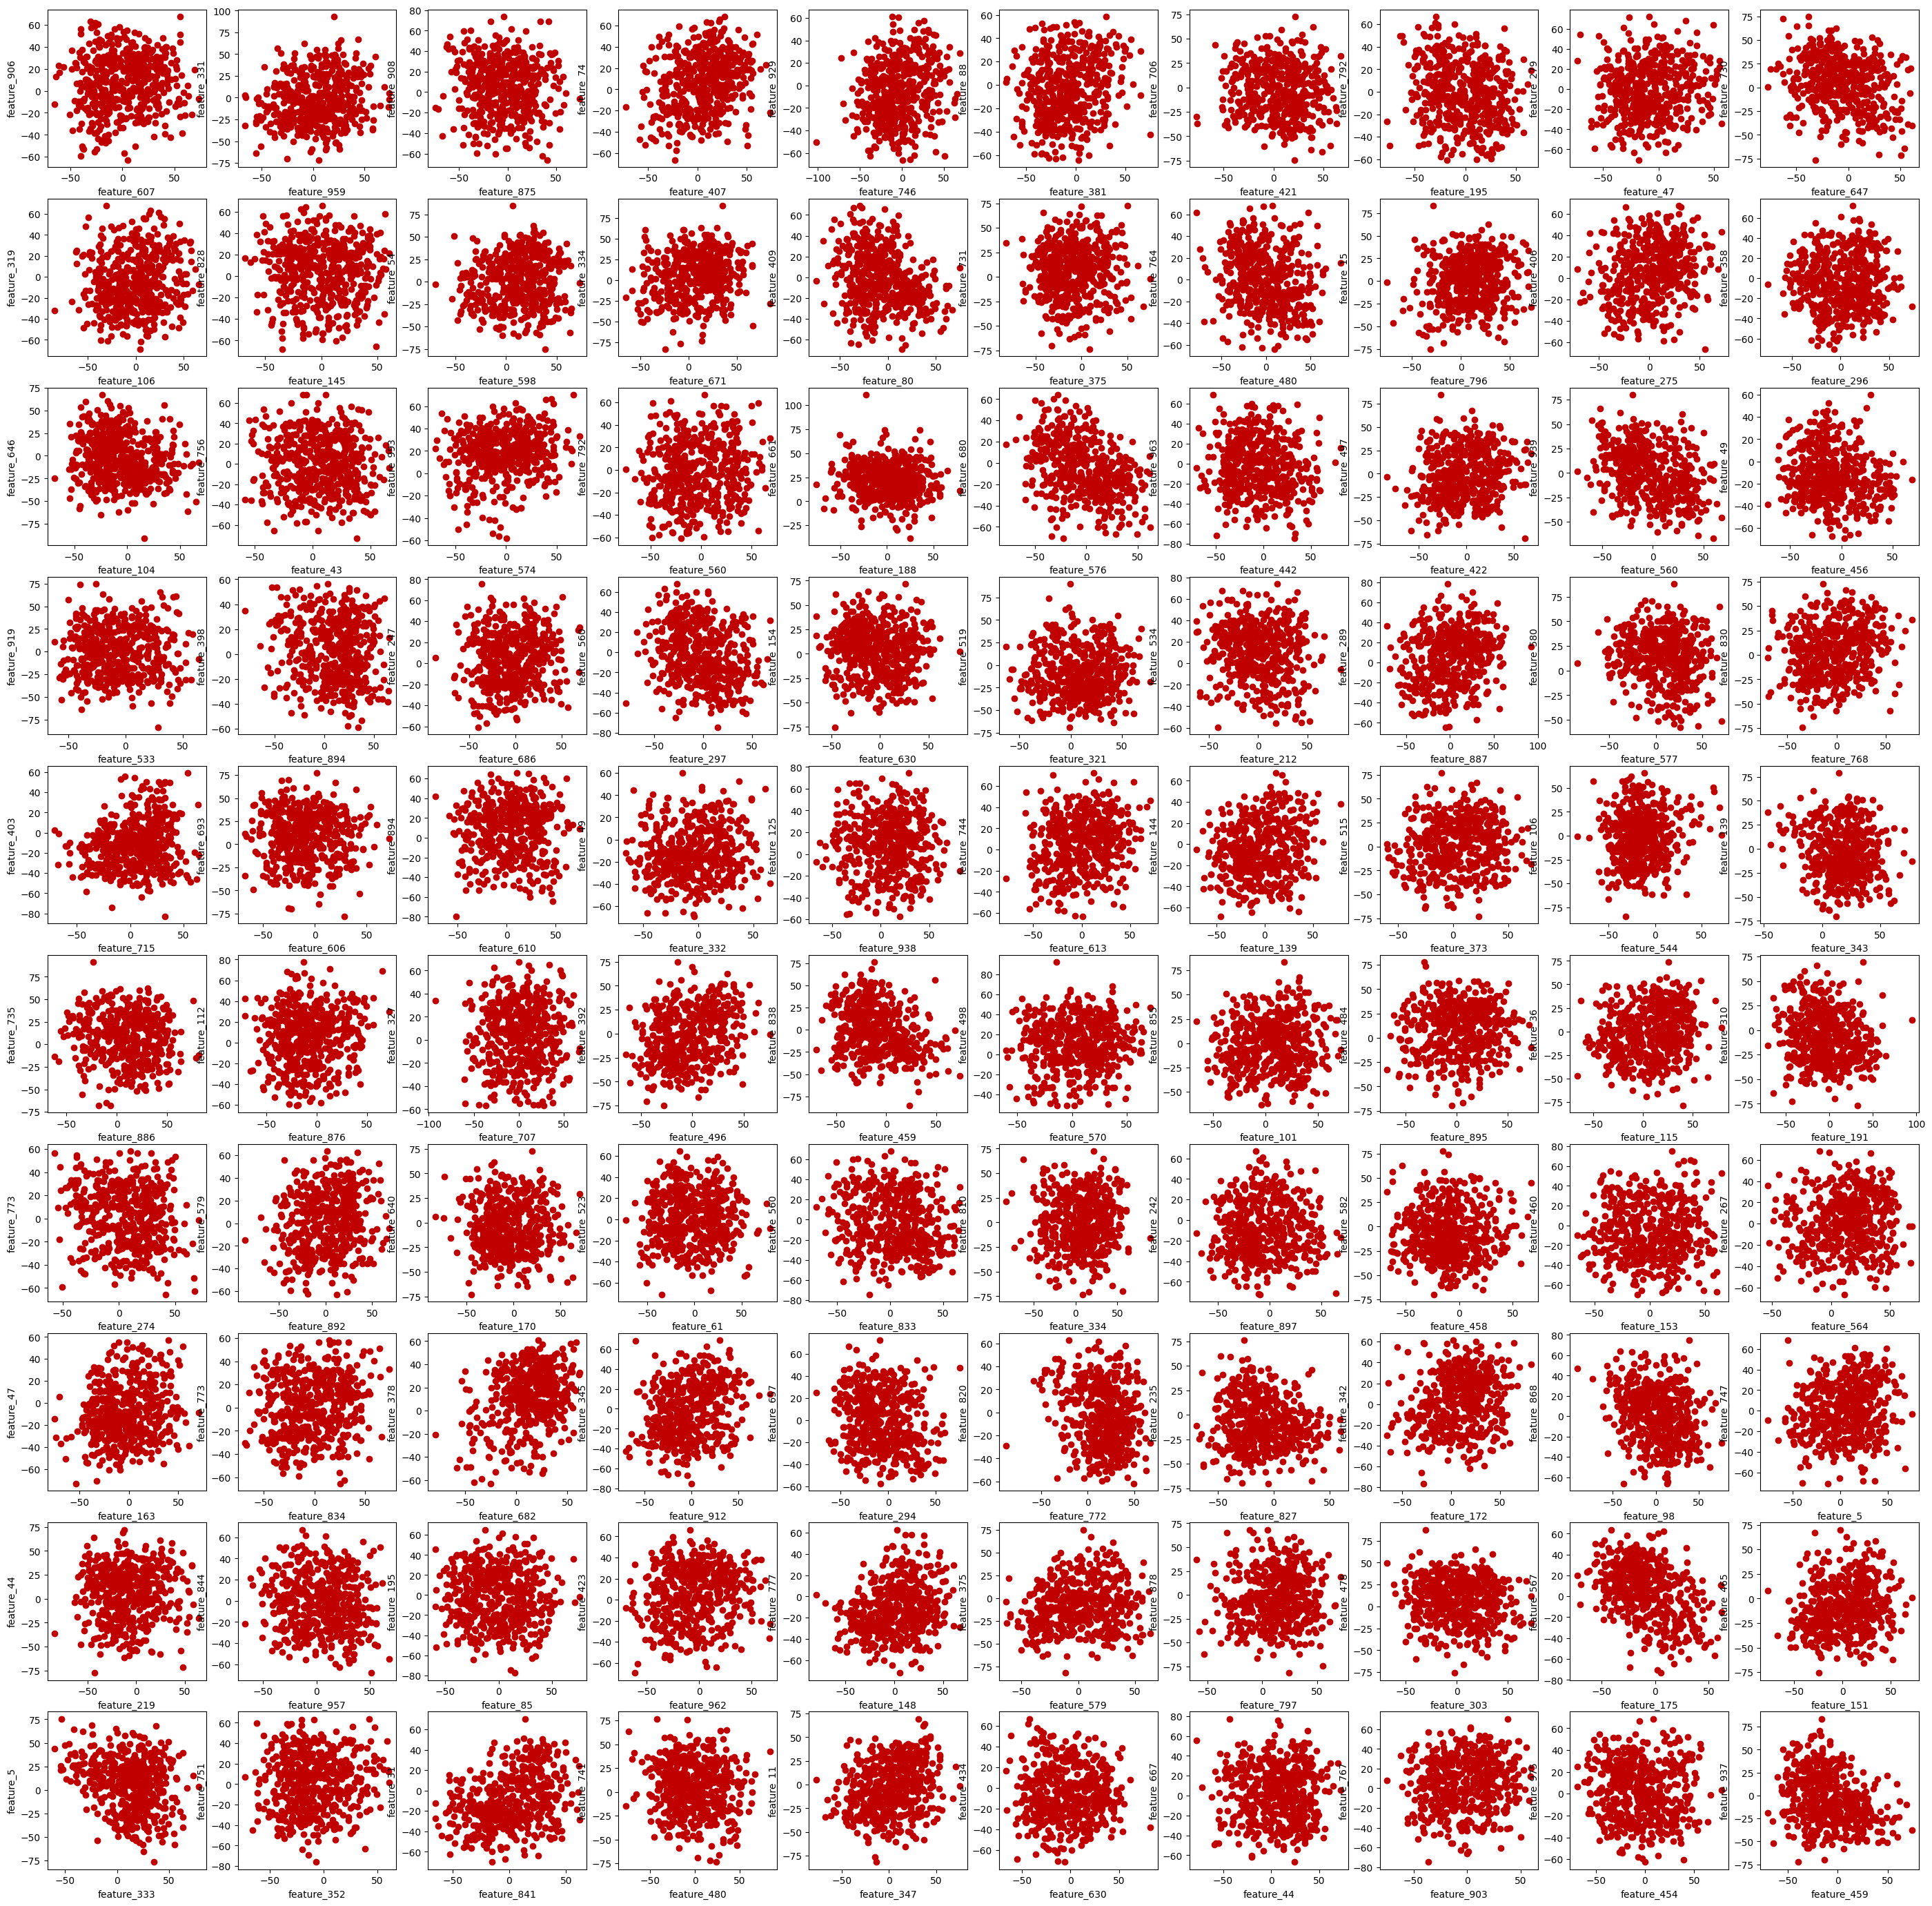

In [63]:
#plot the pairs
fig, axs = plt.subplots(10,10, figsize = (35,35))
i = 0
for rows in axs:
    for ax in rows:
        ax.scatter(df[pairs[i][0]], df[pairs[i][1]], color = '#C00000')
        ax.set_xlabel(pairs[i][0])
        ax.set_ylabel(pairs[i][1])
        i += 1


In [ ]:
#observation
# So many combinations
# Not much info hidden in the pairwise features

In [64]:
#correlation between the pairs
corr = df.corr()

In [65]:
#shows features wth correlaton > 0.5 in absolute value
# We remove the features with correlation == 1to remove the correlation of a feature with itself
mask = (abs(corr) > 0.5) & (abs(corr) != 1)
corr.where(mask).stack().sort_values()

feature_81   feature_657   -0.631294
feature_657  feature_81    -0.631294
feature_313  feature_4     -0.615317
feature_4    feature_313   -0.615317
feature_716  feature_1     -0.609056
                              ...   
feature_792  feature_547    0.620864
feature_35   feature_965    0.631424
feature_965  feature_35     0.631424
feature_395  feature_985    0.632593
feature_985  feature_395    0.632593
Length: 1870, dtype: float64

In [ ]:
#observation - The max and min correlation is ~0.631 - 0.632
# This does not show much as well


In [66]:
#Try PCA decomposition to compree our data into 2D and plot scatter plot
#load the PCA object
pca = PCA(n_components= 2 )
X_pca = pca.fit_transform(df)
df_pca = pd.DataFrame(X_pca, columns = ['principal_component_1', 'principal_component_2'])

In [68]:
df_pca.head()

,principal_component_1,principal_component_2
0,46.235641,-1.672797
1,210.208758,-84.068249
2,26.352795,-127.895751
3,116.106804,-269.368256
4,110.183605,-279.657306


Text(0.5, 1.0, 'PCA decomposition')

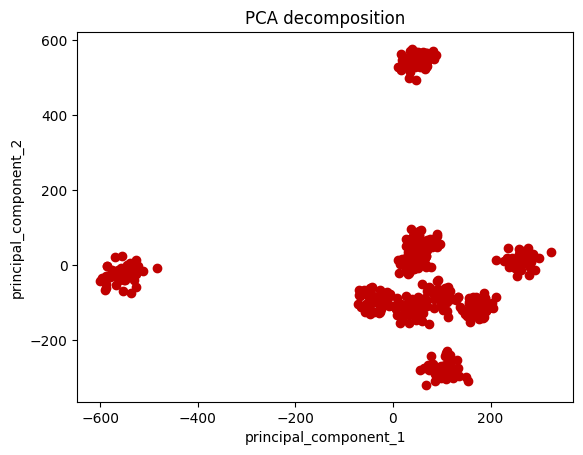

In [69]:
plt.scatter(df_pca['principal_component_1'],df_pca['principal_component_2'], color = "#C00000")
plt.xlabel('principal_component_1')
plt.ylabel('principal_component_2')
plt.title('PCA decomposition')

In [ ]:
#Observation - we can see well defined 8 clusters

In [70]:
# pca.explained_variance_ration_ returns a list where it shows the amount of variance explained by each principal component.
sum(pca.explained_variance_ratio_)

0.14572843555106277

In [71]:
#plt 3D to get more info
pca_3 = PCA(n_components = 3).fit(df)
X_t = pca_3.transform(df)
df_pca_3 = pd.DataFrame(X_t,columns = ['principal_component_1','principal_component_2','principal_component_3'])

In [72]:
import plotly.express as px

In [77]:
fig = px.scatter_3d(df_pca_3, x = 'principal_component_1', y = 'principal_component_2', 
z = 'principal_component_3').update_traces(marker = dict(color = '#C00000'))
fig.show()

In [76]:
sum(pca_3.explained_variance_ratio_)

0.2080625781609329

In [ ]:
#observation - we can see well defined clusters
# preserved ~19% of variance